# Purpose
This notebook conducts sensitive analysis of learning rate $\eta$ in adaptive weight adjustment and generates Fig S26-S28 (Supplementary Note 1).

In [1]:
import pickle
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import sys
sys.path.append("..")
from scripts import stats_analysis, draw

In [2]:
cond_ls = ['A', 'C'] # Weight adjustment condition
pin = 0.5 # proportion of in-link rewiring
eta_ls = [1.0, 10.0, 100.0] # learning rate
tau_ls = [0.05, 0.1, 0.5] # tau_reweight

r2_thresh = 0.85 # threshold of r2 for the power-law fit
num_bins = 20 # number of bins on the logscale for the histogram of the upper tail of the weight distribution
k_rep = 0 # the index of the representative network 

In [3]:
A_wAdjAlone = {}; A_wAdjRand = {}; A_dualAdapt = {}
for cond in cond_ls:
    A_wAdjAlone[cond] = {}; A_wAdjRand[cond] = {}; A_dualAdapt[cond] = {}
    for tau in tau_ls:
        A_wAdjAlone[cond][tau] = {}; A_wAdjRand[cond][tau] = {}; A_dualAdapt[cond][tau] = {}
        for eta in eta_ls:       
            f = open('./Output/wAdjust_alone/'+cond+'_eta_'+str(eta)+'_tau_'+str(tau)+'_'+str(k_rep)+'.pckl', 'rb')
            A_wAdjAlone[cond][tau][eta], _ = pickle.load(f)
            f.close()
            
            f = open('./Output/wAdjust_randRew/'+cond+'_eta_'+str(eta)+'_tau_'+str(tau)+'_'+str(k_rep)+'.pckl', 'rb')
            A_wAdjRand[cond][tau][eta], _ = pickle.load(f)
            f.close()
            
            f = open('./Output/dualAdapt/'+cond+'_pin_'+str(pin)+'_eta_'+str(eta)+'_tau_'+str(tau)+'_'+str(k_rep)+'.pckl', 'rb')
            A_dualAdapt[cond][tau][eta], _ = pickle.load(f)
            f.close()

# Fig S26: Control condition 1

Text(-0.22, 1.05, 'B')

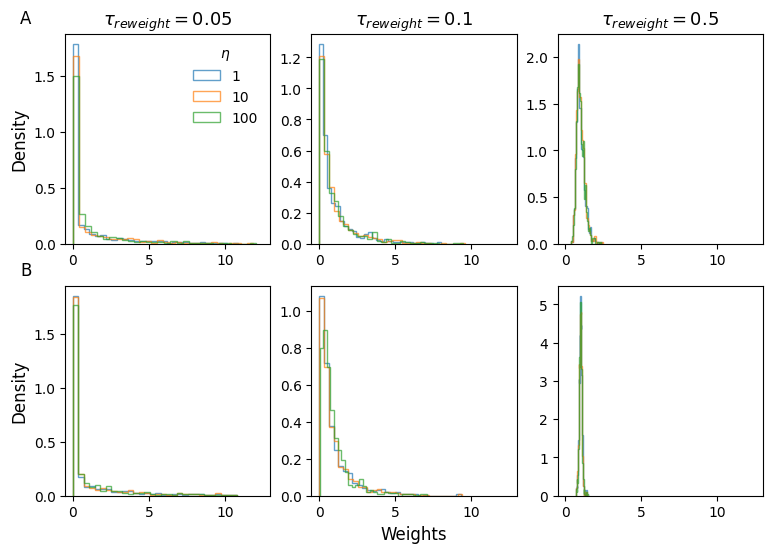

In [4]:
# weight distirbutions of networks performed adaptive weight adjustment alone with fixed connectivity
plt.rcParams["figure.figsize"] = (9, 6)
fig, ax1 = plt.subplots(2, 3)
for i, cond in enumerate(cond_ls):
    for l, tau in enumerate(tau_ls):
        for s, eta in enumerate(eta_ls):
            weights = A_wAdjAlone[cond][tau][eta][A_wAdjAlone[cond][tau][eta]>0]
            ax1[i, l].hist(weights, bins=30, density=True, alpha=0.7, label = str(int(eta)), 
                       histtype=u'step', linewidth=1, )
            ax1[i, l].tick_params(axis = 'both', labelsize=10)
            ax1[i, l].set_xlim([-0.5, 13])
    ax1[i, 0].set_ylabel('Density',fontsize=12)
ax1[0, 0].legend(title = '$\\eta$', frameon=False)
ax1[1, 1].set_xlabel( 'Weights', size=12)

for l, tau in enumerate(tau_ls):
    ax1[0, l].set_title('$\\tau_{reweight} = $'+str(tau), fontsize = 13)
ax1[0, 0].text(-0.22, 1.05, 'A', transform=ax1[0, 0].transAxes, size=12)
ax1[1, 0].text(-0.22, 1.05, 'B', transform=ax1[1, 0].transAxes, size=12)

#plt.savefig('../fig/Fig S26.svg', dpi = 300)

# Fig S27: Control condition 2

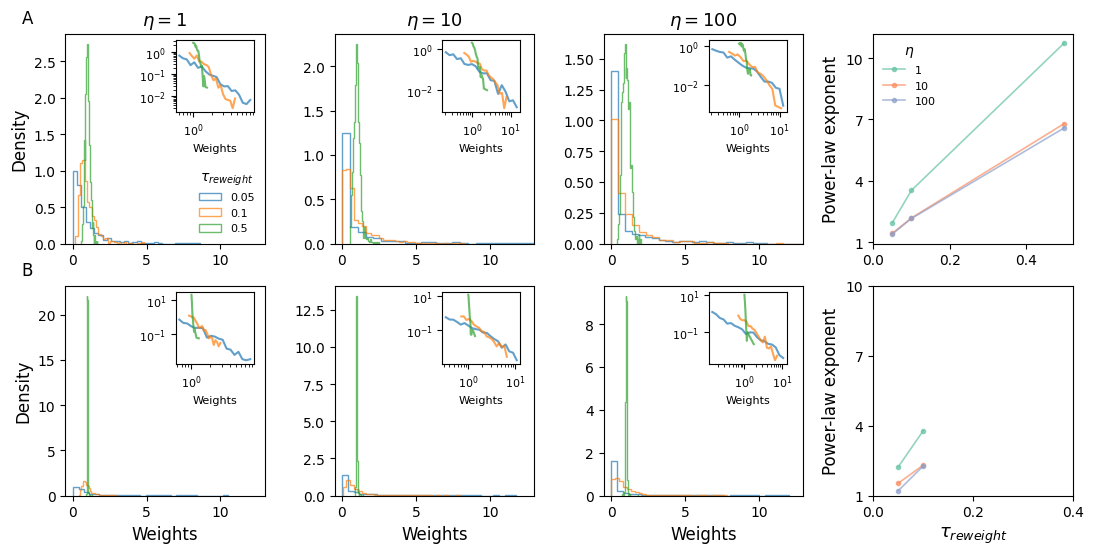

In [5]:
# weight distirbutions of networks performed adaptive weight adjustment and random rewiring
plt.rcParams["figure.figsize"] = (13, 6)
fig, ax1 = plt.subplots(2, 4)
for i, cond in enumerate(cond_ls):
    for s, eta in enumerate(eta_ls):
        # Histogram of weight distributions
        for l, tau in enumerate(tau_ls):
            weights = A_wAdjRand[cond][tau][eta][A_wAdjRand[cond][tau][eta]>0]
            ax1[i, s].hist(weights, bins=30, density=True, alpha=0.7, label = str(tau), 
                       histtype=u'step', linewidth=1, )
            ax1[i, s].tick_params(axis = 'both', labelsize=10)
            ax1[i, s].set_xlim([-0.5, 13])
        # right tail of weight distributions in log-log scale
        left, bottom, width, height = [0.21+s*0.205, 0.75-i*0.42, 0.06, 0.12]
        ax1_1 = fig.add_axes([left, bottom, width, height])
        slope = []
        for l, tau in enumerate(tau_ls):
            res = stats_analysis.PL_MLE(A_wAdjRand[cond][tau][eta], num_bins)    
            if res[2] > r2_thresh:
                slope.append(-res[1])
            else:
                slope.append(np.nan)
            weights = A_wAdjRand[cond][tau][eta][A_wAdjRand[cond][tau][eta]>0]
            draw.draw_power_law(ax1_1, weights, res, tau, num_bins, color = sns.color_palette(palette='tab10', n_colors=5)[l], draw_fit = False)
        ax1_1.set_xlabel('Weights',fontsize=8)
        ax1_1.tick_params(axis = 'both', labelsize=8)
        ax1_1.set_xscale('log')
        ax1_1.set_yscale('log')
        # decay rates of right tails
        ax1[i, 3].plot(tau_ls, slope, color = sns.color_palette("Set2")[s], label = str(int(eta)),alpha = 0.7, marker='o', markersize=3, linewidth=1.2, linestyle='-', zorder=3)
    
    ax1[i, 0].set_ylabel('Density',fontsize=12)
    ax1[i, 3].set_xticks(np.arange(0, 0.6, 0.2))
    ax1[i, 3].set_yticks(np.arange(1, 13, 3))
    ax1[i, 3].set_ylabel('Power-law exponent', fontsize = 12)
    
ax1[1, 3].set_xlabel('$\\tau_{reweight}$', fontsize = 13)
ax1[0, 0].legend(title = '$\\tau_{reweight}$', frameon=False, loc='lower right', fontsize=8)
ax1[0, 3].legend(title = '$\\eta$', frameon=False, fontsize=8)
for s, eta in enumerate(eta_ls):
    ax1[0, s].set_title('$\\eta = $'+str(int(eta)), fontsize = 13)
    ax1[1, s].set_xlabel( 'Weights', size=12)
ax1[0, 0].text(-0.22, 1.05, 'A', transform=ax1[0, 0].transAxes, size=12)
ax1[1, 0].text(-0.22, 1.05, 'B', transform=ax1[1, 0].transAxes, size=12)
fig.subplots_adjust(wspace = 0.35)

#plt.savefig('../fig/Fig S27.svg', dpi = 300)

# Fig S28: Dual adaptive algorithm

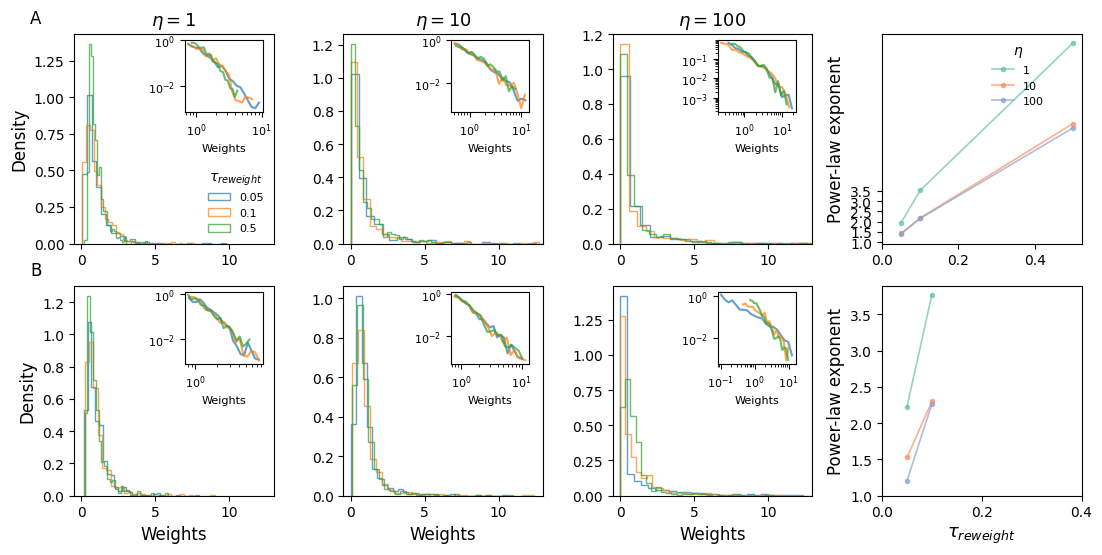

In [6]:
# weight distirbutions of networks performed adaptive weight adjustment and adaptive rewiring
plt.rcParams["figure.figsize"] = (13, 6)
fig, ax1 = plt.subplots(2, 4)
for i, cond in enumerate(cond_ls):
    for s, eta in enumerate(eta_ls):
        for l, tau in enumerate(tau_ls):
            weights = A_dualAdapt[cond][tau][eta][A_dualAdapt[cond][tau][eta]>0]
            ax1[i, s].hist(weights, bins=30, density=True, alpha=0.7, label = str(tau), 
                       histtype=u'step', linewidth=1, )
            ax1[i, s].tick_params(axis = 'both', labelsize=10)
            ax1[i, s].set_xlim([-0.5, 13])
        # right tail of weight distributions in log-log scale
        left, bottom, width, height = [0.21+s*0.205, 0.75-i*0.42, 0.06, 0.12]
        ax1_1 = fig.add_axes([left, bottom, width, height])
        slope = []
        for l, tau in enumerate(tau_ls):
            res = stats_analysis.PL_MLE(A_wAdjRand[cond][tau][eta], num_bins)        
            if res[2] > r2_thresh:
                slope.append(-res[1])
            else:
                slope.append(np.nan)
            weights = A_dualAdapt[cond][tau][eta][A_dualAdapt[cond][tau][eta]>0]
            draw.draw_power_law(ax1_1, weights, res, tau, num_bins, color = sns.color_palette(palette='tab10', n_colors=5)[l], draw_fit = False)
        ax1_1.set_xlabel('Weights',fontsize=8)
        ax1_1.tick_params(axis = 'both', labelsize=8)
        ax1_1.set_xscale('log')
        ax1_1.set_yscale('log')
        # decay rates of right tails
        ax1[i, 3].plot(tau_ls, slope, color = sns.color_palette("Set2")[s], label = str(int(eta)),alpha = 0.7, marker='o', markersize=3, linewidth=1.2, linestyle='-', zorder=3)
    
    ax1[i, 0].set_ylabel('Density',fontsize=12)
    ax1[i, 3].set_xticks(np.arange(0, 0.6, 0.2))
    ax1[i, 3].set_yticks(np.arange(1, 4, 0.5))
    ax1[i, 3].set_ylabel('Power-law exponent', fontsize = 12)
    
ax1[1, 3].set_xlabel('$\\tau_{reweight}$', fontsize = 13)
ax1[0, 0].legend(title = '$\\tau_{reweight}$', frameon=False, loc='lower right', fontsize=8)
ax1[0, 3].legend(title = '$\\eta$', frameon=False, fontsize=8, bbox_to_anchor = (0.5, 0.5, 0.5, 0.5))
for s, eta in enumerate(eta_ls):
    ax1[0, s].set_title('$\\eta = $'+str(int(eta)), fontsize = 13)
    ax1[1, s].set_xlabel( 'Weights', size=12)
ax1[0, 0].text(-0.22, 1.05, 'A', transform=ax1[0, 0].transAxes, size=12)
ax1[1, 0].text(-0.22, 1.05, 'B', transform=ax1[1, 0].transAxes, size=12)
fig.subplots_adjust(wspace = 0.35)

#plt.savefig('../fig/Fig S28.svg', dpi = 300)